# DART 이벤트 스터디 — 결과 리포트 (v1.2)

**유니버스**: 2019-01 기준 프록시 시총 상위 200 KOSPI 보통주, 기간 내 상폐 종목 포함
(v1.2 survivorship 보정 — 한계 참조) · **기간**: 2019-01-01 ~ 2024-12-31

**이벤트 3종**: 자사주매입(직접취득) / 유상증자 / 실적공시(잠정실적)

**핵심 설계**: 여론 감성이 아니라 공시의 **구조화 정보 + 방향 룰**. Look-ahead 방지를 위해 모든 시그널은
접수일 **익영업일 종가** 체결 가정(접수시각 미제공 — 보수적), 수정주가 사용, 거래정지일 체결 밀기,
거래비용 = 시행일별 거래세 스케줄(0.30→0.18%) + 슬리피지 0.10% + 수수료 0.015% (편도).

**재현**: 레포 루트에서 `uv sync` → `.env`에 `OPENDART_API_KEY` → 파이프라인 실행(README 참조) 후 이 노트북 실행.
모든 원천 응답은 `data/`에 캐시되므로 재실행이 빠르다. 신뢰도 진단·보정 이력은 RELIABILITY_AUDIT.md.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import yaml

DATA = Path("..") / "data"
MODE = "full"

# 차트 팔레트 — dataviz 검증기 통과 (CVD ΔE 16.2, aqua는 직접 라벨로 보완)
C_BLUE, C_AQUA, C_RED, C_ORANGE = "#2a78d6", "#1baf7a", "#e34948", "#eb6834"
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": BASE, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    # 차트 문자열은 ASCII 하이픈만 사용 — Malgun Gothic에 U+2212(−) 글리프 없음 (v1.1 [2])
    "font.sans-serif": ["Malgun Gothic", "DejaVu Sans"], "axes.unicode_minus": False,
})

events = pd.read_parquet(DATA / f"events_{MODE}.parquet")
signals = pd.read_parquet(DATA / f"signals_{MODE}.parquet")
car = pd.read_parquet(DATA / f"eventstudy_{MODE}" / "car_summary.parquet")
aar = pd.read_parquet(DATA / f"eventstudy_{MODE}" / "aar_curves.parquet")
bt = pd.read_parquet(DATA / f"backtest_{MODE}.parquet")
settings = yaml.safe_load((Path("..") / "config" / "settings.yaml").read_text(encoding="utf-8"))
print(f"이벤트 {len(events):,}건 / 시그널 {len(signals):,}건")

이벤트 5,723건 / 시그널 4,650건


## 1. 표본 (전부 공개 — 다중검정 원칙)

이벤트별 표본 수와 방향 분포 (v1.2 유니버스: 2019 기준 200종 + 상폐 11종).
실적 방향 판정 불가 ~13%는 원문 미제공(구형 공시) + 표 형식 변형 때문이며 시그널에서 제외했다.
서프라이즈 기준은 영업이익 YoY. 전년동기 결측 시 QoQ를 참고 피처로 계산하지만(`surprise_basis` 기록)
**시그널에서는 제외한다** — QoQ는 계절성을 서프라이즈로 오인할 수 있어 YoY와 다른 것을 측정하기 때문
(v1.1 민감도: 제외 전후 실질 동일 확인).

In [2]:
tbl = events.pivot_table(index="event_type", columns="direction", values="rcept_no",
                         aggfunc="count", dropna=False, fill_value=0)
tbl["판정불가"] = events[events["direction"].isna()].groupby("event_type").size()
tbl["합계"] = events.groupby("event_type").size()
display(tbl.fillna(0).astype(int))
print("실적 서프라이즈 기준:", events[events.event_type == "earnings"]["surprise_basis"].value_counts(dropna=False).to_dict())

direction,-1.0,0.0,1.0,NaN,판정불가,합계
event_type,,,,,,
buyback,0,0,178,0,0,178
buyback_trust,0,0,106,0,0,106
earnings,1868,1,2495,936,936,5300
rights_offering,50,65,24,0,0,139


실적 서프라이즈 기준: {'yoy': 4295, nan: 936, 'qoq': 69}


## 2. 이벤트 스터디 — 정보력은 실재한다

시장모형(KOSPI, 추정 120거래일·갭 10일) 잔차의 누적 평균(CAAR). day 0 = 접수일 이후 첫 거래일.

**유의성은 세 가지 t + FDR q값을 병기한다**: `t_naive`는 이벤트 독립을 가정하는데, 실적공시는
어닝시즌에 날짜가 뭉쳐(실적 시그널 4,294건이 523일에 발생, 최대 하루 48건) 잔차가 단면 상관을
갖고 naive t가 과대추정된다. 이를 **이벤트 day0 날짜 / 발생 월로 클러스터링한 로버스트
SE(CR1, df = 클러스터수-1)**로 재검정하고, 15개 검정 동시 수행을 반영해 월CL p에
**Benjamini–Hochberg FDR q값**을 추가했다 (v1.2). 유의 판정은 q < 5% 기준 — 경계 유의가
보정에서 탈락하면 탈락한 대로 리포트한다.

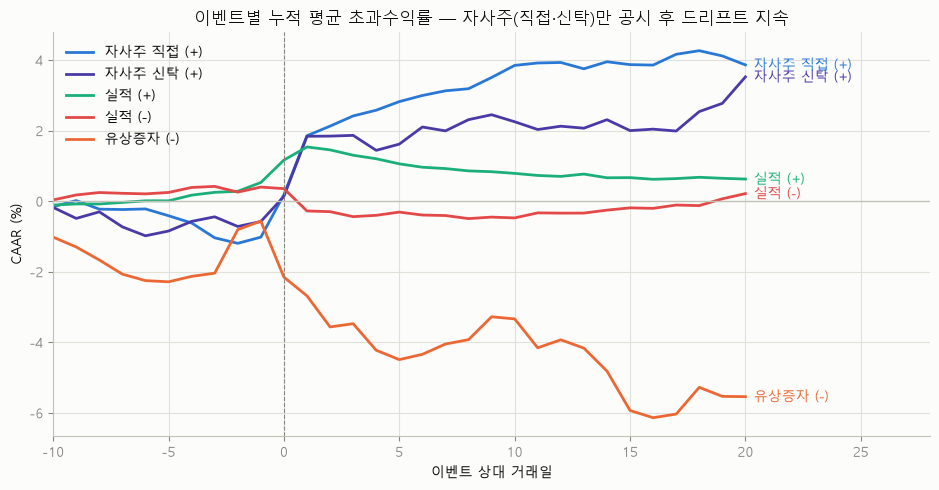

In [3]:
C_VIOLET = "#4a3aa7"  # 5색 팔레트 재검증 통과 (CVD ΔE 16.2)
groups = {
    ("buyback", 1): ("자사주 직접 (+)", C_BLUE),
    ("buyback_trust", 1): ("자사주 신탁 (+)", C_VIOLET),
    ("earnings", 1): ("실적 (+)", C_AQUA),
    ("earnings", -1): ("실적 (-)", C_RED),
    ("rights_offering", -1): ("유상증자 (-)", C_ORANGE),
}
fig, ax = plt.subplots(figsize=(9.5, 5))
for (et, d), (label, color) in groups.items():
    g = aar[(aar.event_type == et) & (aar.direction == d)].sort_values("rel_day")
    caar = g.set_index("rel_day")["aar"].cumsum() * 100
    ax.plot(caar.index, caar.values, color=color, linewidth=2, label=label)
    ax.annotate(label, (caar.index[-1], caar.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=color, fontsize=10, va="center")
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle="--")
ax.axhline(0, color=BASE, linewidth=1)
ax.set_xlabel("이벤트 상대 거래일")
ax.set_ylabel("CAAR (%)")
ax.set_title("이벤트별 누적 평균 초과수익률 — 자사주(직접·신탁)만 공시 후 드리프트 지속")
ax.legend(frameon=False, loc="upper left")
ax.set_xlim(-10, 28)
plt.tight_layout()
plt.show()

In [4]:
t = car.copy()
t["mean_car(%)"] = (t["mean_car"] * 100).round(2)
stat_cols = ["t_naive", "p_naive", "t_cl_day", "t_cl_month", "p_cl_month", "q_cl_month"]
t[stat_cols] = t[stat_cols].round(3)
t["유의(q<5%)"] = (t["q_cl_month"] < 0.05).map({True: "✓", False: ""})
t["표본유보"] = t["thin_sample"].map({True: "⚠️", False: ""})
display(t[["event_type", "direction", "window", "N", "n_cl_day", "n_cl_month", "mean_car(%)"]
          + stat_cols + ["유의(q<5%)", "표본유보"]])
print("n_cl_* = 클러스터 수. 자사주는 169건/158일 — 사실상 독립이라 클러스터링 영향 미미.")
print("FDR 보정 생존: 자사주 전 윈도우, 실적± 공시창 [-1,1], 유증- [0,5]. 실적 [0,5]는 q=6%로 탈락.")

,event_type,direction,window,N,n_cl_day,n_cl_month,mean_car(%),t_naive,p_naive,t_cl_day,t_cl_month,p_cl_month,q_cl_month,유의(q<5%),표본유보
0,buyback,1,"[-1,1]",169,158,58,3.05,8.251,0.000,8.073,7.468,0.000,0.000,✓,
1,buyback,1,"[0,5]",169,158,58,3.84,7.975,0.000,7.495,6.443,0.000,0.000,✓,
2,buyback,1,"[0,20]",169,158,58,4.88,5.818,0.000,5.709,4.882,0.000,0.000,✓,
3,buyback_trust,1,"[-1,1]",104,96,44,2.56,5.222,0.000,5.139,4.625,0.000,0.000,✓,
4,buyback_trust,1,"[0,5]",104,96,44,2.19,2.790,0.006,2.690,2.160,0.036,0.060,,
5,buyback_trust,1,"[0,20]",104,96,44,4.10,3.134,0.002,2.915,2.656,0.011,0.027,✓,
6,earnings,-1,"[-1,1]",1767,404,51,-0.53,-4.446,0.000,-3.397,-2.608,0.012,0.027,✓,
7,earnings,-1,"[0,5]",1767,404,51,-0.71,-4.490,0.000,-2.966,-2.197,0.033,0.059,,
8,earnings,-1,"[0,20]",1767,404,51,-0.18,-0.731,0.465,-0.483,-0.311,0.757,0.801,,
9,earnings,1,"[-1,1]",2391,461,51,1.26,11.614,0.000,8.933,6.896,0.000,0.000,✓,


n_cl_* = 클러스터 수. 자사주는 169건/158일 — 사실상 독립이라 클러스터링 영향 미미.
FDR 보정 생존: 자사주 전 윈도우, 실적± 공시창 [-1,1], 유증- [0,5]. 실적 [0,5]는 q=6%로 탈락.


## 3. 백테스트 — 체결가능 수익은 보정 사다리를 거치며 소멸한다

익영업일 종가 진입, H거래일 보유, 균등가중, |Δw| 기반 비용(시행일별 거래세+슬리피지+수수료),
손실형 상폐 청산 할인 30%, 거래정지일 체결 밀기. 아래 NAV는 자사주-only(H=5), 전체 시그널(H=5), KOSPI.

자사주 H=5의 보정 사다리 (v1.1 → v1.2): net 연 +5.1% (스냅샷 유니버스·고정세율)
→ +3.8% (2019 유니버스·상폐 처리) → **+2.4%** (실효 세율·수수료), Sharpe 0.21 → 0.11 (KOSPI 0.16).

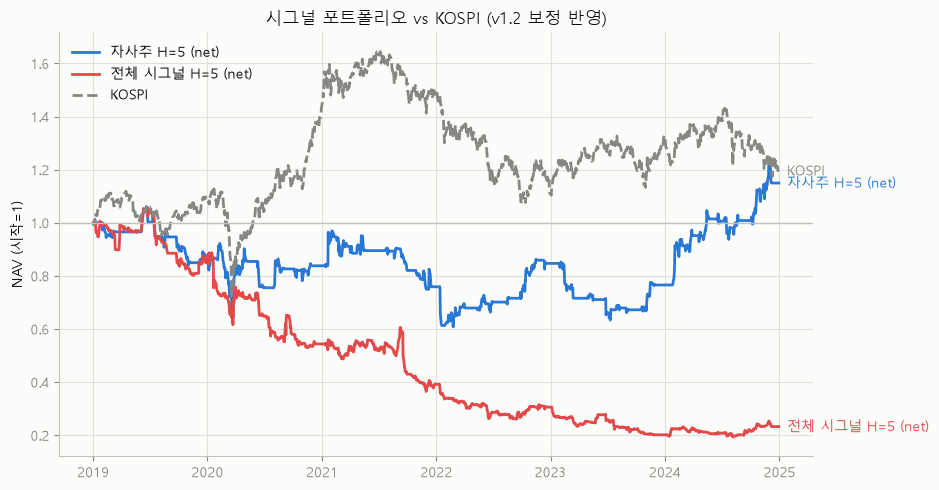

In [5]:
from quantlab_shared.backtest.costs import KOSPI_TAX_SCHEDULE, CostModel
from quantlab_shared.backtest.engine import run_backtest
from quantlab_shared.data.prices import PriceStore

from dart_event_study.config import resolve_universe_asof

start, end = settings["period"]["start"], settings["period"]["end"]
c = settings["costs"]
cost = CostModel(
    transaction_tax=c["transaction_tax"], slippage=c["slippage"],
    commission=c.get("commission", 0.0),
    tax_schedule=KOSPI_TAX_SCHEDULE if c.get("use_tax_schedule") else None,
)
store = PriceStore(DATA / "prices", start, end)
tickers = signals["ticker"].unique()
closes = pd.DataFrame({tk: store.ohlcv(tk)["close"] for tk in tickers})
volumes = pd.DataFrame({tk: store.ohlcv(tk)["volume"] for tk in tickers})
delist_loss = set(resolve_universe_asof()["delisted_loss"])
kw = dict(cost=cost, delist_discount=settings["backtest"]["delist_discount"],
          delist_tickers=delist_loss, volumes=volumes)

res_bb = run_backtest(signals[signals.event_type == "buyback"], closes, 5, **kw)
res_all = run_backtest(signals, closes, 5, **kw)
kospi_ret = store.ohlcv("KS11")["close"].pct_change().fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 5))
for daily, label, color, style in [
    (res_bb.daily_net, "자사주 H=5 (net)", C_BLUE, "-"),
    (res_all.daily_net, "전체 시그널 H=5 (net)", C_RED, "-"),
    (kospi_ret, "KOSPI", MUTED, "--"),
]:
    nav = (1 + daily).cumprod()
    ax.plot(nav.index, nav.values, color=color, linewidth=2, linestyle=style, label=label)
    ax.annotate(label, (nav.index[-1], nav.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=color, fontsize=10, va="center")
ax.axhline(1, color=BASE, linewidth=1)
ax.set_ylabel("NAV (시작=1)")
ax.set_title("시그널 포트폴리오 vs KOSPI (v1.2 보정 반영)")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
cols = ["scope", "H", "variant", "ann_return", "sharpe", "sortino", "mdd", "turnover_ann", "hit_ratio", "n_trades"]
display(bt[cols].round(3))

,scope,H,variant,ann_return,sharpe,sortino,mdd,turnover_ann,hit_ratio,n_trades
0,all,5,long_short,-0.220,-0.906,-1.021,-0.817,59.686,0.442,4639.0
1,all(gross),5,long_short,0.024,0.100,0.105,-0.455,59.686,0.442,4639.0
2,all,5,long_only,-0.209,-0.808,-0.980,-0.818,54.968,0.433,2747.0
3,all(gross),5,long_only,0.016,0.062,0.072,-0.459,54.968,0.433,2747.0
4,buyback,5,long_short,0.024,0.105,0.107,-0.427,25.459,0.528,176.0
5,buyback,5,long_only,0.024,0.105,0.107,-0.427,25.459,0.528,176.0
6,buyback_trust,5,long_short,0.016,0.085,0.071,-0.410,15.667,0.519,106.0
7,buyback_trust,5,long_only,0.016,0.085,0.071,-0.410,15.667,0.519,106.0
8,earnings,5,long_short,-0.201,-1.157,-0.931,-0.737,42.558,0.434,4287.0
9,earnings,5,long_only,-0.182,-0.881,-0.724,-0.708,39.431,0.423,2442.0


## 4. 결론 (v1.2 + 신탁 확장)

1. **공시의 정보력은 보정을 전부 통과할 만큼 강건하다.** 월클러스터 t + FDR q<5% 기준 생존:
   자사주 직접 전 윈도우 ([0,+20] +4.88%, t 5.8→4.9), **신탁 자사주 [-1,+1]·[0,+20] +4.10%**
   (별도 그룹 독립 재현 — 강도는 직접보다 약함, 계약≠매수 확약), 실적± 공시창 [-1,+1],
   유증− [0,+5] −3.93%. 경계 유의였던 실적 [0,+5]는 FDR 보정에서 탈락 — 탈락한 대로 기록.
2. **체결가능한 초과수익은 보정 사다리에서 소멸했다.** 자사주 직접 H=5:
   v1.1 +5.1%/0.21 → 유니버스 보정(승자 편향 제거) +3.8%/0.17 → 실효 비용 +2.4%/0.11
   (KOSPI +3.1%/0.16). v1.1의 "간신히 생존"은 상당 부분 **승자 편향과 비용 과소평가의 산물**이었다.
3. **우연과 구분 불가 — 새 최선 조합도 같은 잣대로.** 직접 H=5: 부트스트랩 CI [−0.57, +0.97],
   DSR 7%. 신탁 H=20이 net +12.2%/Sharpe 0.46로 새로운 최선이지만 시도 20개 조합의
   사후 선택 — CI [−0.30, +1.49], **DSR 16.8%**로 역시 우연과 구분 불가.
   서브기간도 국면 의존: 직접 H=5 기준 2019–21 연 −8.9% vs 2022–24 +15.3%.
4. **최종 결론**: 공시 정보는 가격에 빠르게, 대부분 하루 안에 반영된다. 자사주 드리프트라는
   현상은 직접·신탁 두 채널에서 독립적으로 재현될 만큼 통계적으로 실재하지만,
   look-ahead 없는 타이밍·현실적 비용·정직한 유니버스·시도 수 보정 아래서
   체계적으로 수확 가능한 초과수익은 이 데이터에서 확인되지 않았다.
   **이 보정 사다리(v1→v1.2)의 정량화가 이 프로젝트의 기여다.**

### 한계
- 유니버스 프록시: 주식수 × 2019-01 수정종가 (유증 종목 과대). 기간 중 신규 상장 미편입 (보수적)
- 접수시각 미확보 → 전 건 익영업일 체결 (당일 체결 기회를 버리는 보수적 편향)
- 실적 이벤트 ~13% 방향 판정 불가 (원문 미제공·표 형식 변형), QoQ 폴백 시그널 제외
- 상폐 청산 할인 30%는 파라미터 가정, 시장충격 미모델링 — 슬리피지 민감도:
  0.1/0.3/0.5%에서 자사주 직접 H=5 net +2.4%/−7.5%/−16.5% (취약한 마진)
- 유상증자 방향성 시그널 73건 — 세분 시 표본 얇음, 숏 제약 미반영
- 컨센서스 부재 → YoY 대용치. 수익률은 배당 제외 (벤치마크와 일관)
- Sharpe 관행: 백테스트 표 = 기하 연환산, significance = 산술 (학계 관행) — 값이 다른 이유